###Implementation of MCP Neurons

<b>AND Gate</b>

In [1]:
def MCP_Neurons_AND(X1, X2, T):
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        summation = X1[i] + X2[i]

        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2

result = MCP_Neurons_AND(X1, X2, T)
print(result)

[0, 0, 0, 1]


<b>OR Gate</b>

In [2]:
def MCP_Neurons_OR(X1, X2, T):
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        summation = X1[i] + X2[i]

        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example
T = 1
result_or = MCP_Neurons_OR(X1, X2, T)
print(result_or)

[0, 1, 1, 1]



<h3 style="color:#4CAF50;">Question 1: Limitations of MCP Neuron</h3>

<p><b>Answer:</b></p>

<p>
The MCP neuron is a very basic and simplified model of a biological neuron. Because of this simplicity, it has several important limitations.
It cannot learn from data since the weights are fixed and there is no learning rule. It only works with binary inputs and outputs, which limits
its flexibility in handling real-world data. Another major limitation is that it cannot solve non-linear problems such as XOR.
Also, it does not have any mechanism to adjust itself based on errors, meaning it cannot improve its performance over time.
Due to all these reasons, MCP neuron is not suitable for complex machine learning tasks.
</p>

<hr>

<h3 style="color:#4CAF50;">Question 2: XOR using MCP Neuron</h3>

<p><b>Answer:</b></p>

<p>
No, a single MCP neuron cannot solve the XOR function. The main reason is that XOR is a non-linear problem, while MCP neuron
can only represent linear decision boundaries. Even if we try to design if-else rules manually, a single neuron will fail to
separate the inputs correctly. To solve XOR, we need multiple neurons arranged in layers (like in neural networks).
So, MCP neuron alone is not enough to solve XOR.
</p>

###TASK 2 :- PERCEPTRON (0 vs 1)

#####Load Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_0_1 = pd.read_csv("/content/mnist_0_and_1.csv")

X = df_0_1.drop(columns=["label"]).values
y = df_0_1["label"].values

print(X.shape)
print(y.shape)

(2312, 784)
(2312,)


<h3 style="color:#2196F3;">Question 1: What does the shape of X represent?</h3>

<p><b>Answer:</b></p>

<p>
The shape of X represents the structure of the dataset. It tells us how many samples (images) are present and how many features
each sample has. In this case, each row corresponds to one image and each column corresponds to one pixel value.
So, it basically shows the size and dimensionality of the input data.
</p>

<hr>

<h3 style="color:#2196F3;">Question 2: What does the shape of y represent?</h3>

<p><b>Answer:</b></p>

<p>
The shape of y represents the labels associated with each input sample. Each value in y corresponds to one image in X
and indicates whether the image belongs to class 0 or class 1.
</p>


#####Visualization

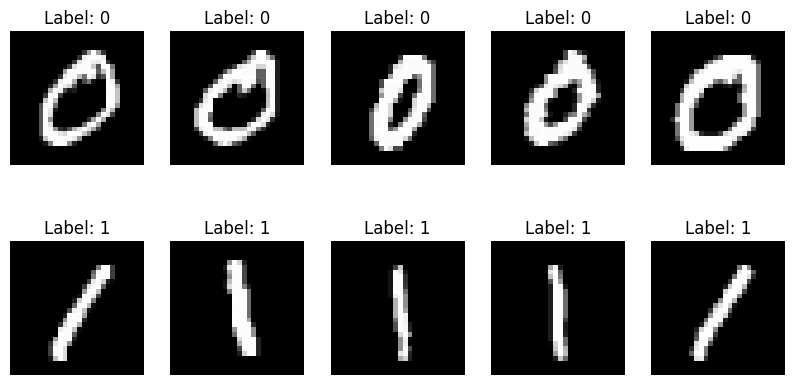

In [5]:
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 0")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 1")
    axes[1, i].axis("off")

plt.show()

#####Initialize

In [6]:
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 100

<hr>

<h3 style="color:#2196F3;">Question 3: What does the weights array represent in this context?</h3>

<p><b>Answer:</b></p>

<p>
The weights array represents how important each feature (pixel) is for making predictions. Each weight is associated
with a specific pixel, and it determines how much that pixel contributes to the final decision of the model.
During training, these weights are adjusted to improve accuracy.
</p>

<hr>

<h3 style="color:#2196F3;">Question 4: Why are we initializing the weights to zero?</h3>

<p><b>Answer:</b></p>

<p>
Weights are initialized to zero to start the learning process from a neutral state where no feature is given importance.
This makes the implementation simple and easy to understand. However, starting with zero weights may make the learning
process slower at the beginning because the model has to gradually adjust all weights from scratch.
</p>

#####Decision Function

In [7]:
def decision_function(X, weights, bias):
    predictions = np.dot(X, weights) + bias
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

#####Train Perceptron

In [8]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):

    for epoch in range(epochs):
        for i in range(len(X)):

            output = np.dot(X[i], weights) + bias
            y_pred = 1 if output >= 0 else 0

            if y_pred != y[i]:
                weights = weights + learning_rate * (y[i] - y_pred) * X[i]
                bias = bias + learning_rate * (y[i] - y_pred)

    # Accuracy
    y_pred_all = np.where(np.dot(X, weights) + bias >= 0, 1, 0)
    accuracy = np.mean(y_pred_all == y)

    return weights, bias, accuracy

<hr>

<h3 style="color:#2196F3;">Question 5: What is the purpose of output = np.dot(X[i], weights) + bias?</h3>

<p><b>Answer:</b></p>

<p>
This line computes the weighted sum of the input features and adds the bias term. It is the core computation of the perceptron,
which determines how strongly the input activates the neuron. Based on this value, the model decides whether to classify
the input as 0 or 1.
</p>

<hr>

<h3 style="color:#2196F3;">Question 6: What happens when the prediction is wrong?</h3>

<p><b>Answer:</b></p>

<p>
When the prediction is wrong, the perceptron updates its weights and bias using the learning rule.
The weights are adjusted based on the error and the input values so that the model can make a better prediction next time.
This process helps the model gradually reduce errors and improve its accuracy over time.
</p>

<hr>

<h3 style="color:#2196F3;">Question 7: Why is the final accuracy important?</h3>

<p><b>Answer:</b></p>

<p>
Final accuracy tells us how well the model has learned from the data. It shows the percentage of correct predictions made by the model.
For a simple classification like 0 vs 1, we expect the accuracy to be very high because the data is relatively easy to separate.
</p>


#####Train Model

In [9]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("Accuracy:", accuracy)

Accuracy: 0.47058823529411764


#####Misclassified Images

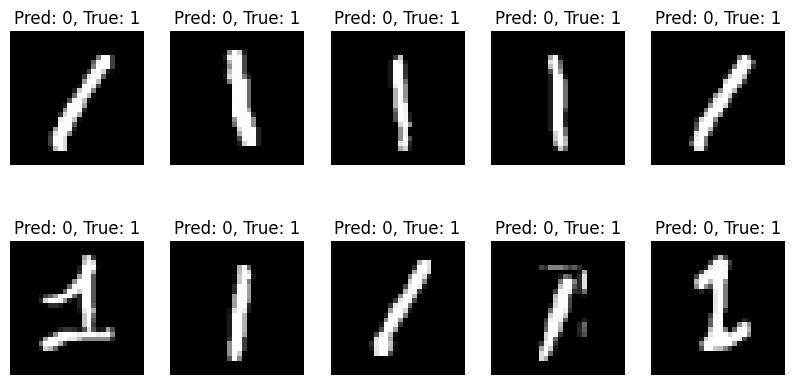

In [10]:
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.show()
else:
    print("All images were correctly classified!")

<h3 style="color:#2196F3;">Question 8: What does misclassified_idx store?</h3>

<p><b>Answer:</b></p>

<p>
The variable misclassified_idx stores the indices of all the samples where the model made incorrect predictions.
These indices are then used to visualize the misclassified images so that we can understand where the model is failing.
</p>

<hr>

<h3 style="color:#2196F3;">Question 9: How do you interpret "All images were correctly classified"?</h3>

<p><b>Answer:</b></p>

<p>
This means that the model has successfully predicted all the samples without any errors.
In other words, the model achieved perfect accuracy on the dataset, which indicates very good performance.
</p>

<hr>

###TASK 3 :- (3 vs 5)

#####Change Dataset

In [12]:
df_3_5 = pd.read_csv("/content/mnist_3_and_5.csv")

X = df_3_5.drop(columns=["label"]).values
y = df_3_5["label"].values

y = np.where(y == 3, 0, 1)

weights = np.zeros(X.shape[1])
bias = 0

weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("Accuracy:", accuracy)

Accuracy: 0.986866107260124


<h3 style="color:#FF5722;">Conclusion</h3>

<p>
In the case of 3 vs 5 classification, the perceptron does not perform as perfectly as in 0 vs 1.
This is because digits 3 and 5 are more similar in shape, making the classification problem harder.
As a result, the model makes more mistakes. This shows the limitation of perceptron when dealing with more complex
and less separable data.
</p>